# Chandra 2 — figure and caption extraction test

Runs [Chandra 2](https://github.com/datalab-to/chandra) (5B parameters, Qwen3.5-based) over
10 pages of *The People's Common Sense Medical Adviser* (1890) and records which layout
blocks it returns, where they sit on the page, and what text it attaches to each figure.

## Notebook settings

| setting | value |
|---|---|
| Accelerator | GPU T4 x2 |
| Internet | On, for `pip install` and a ~10 GB weight download |
| Dataset | `pierce-peoples-common-sense-medical-adviser-1890` |

### P100 does not work

Kaggle's preinstalled torch 2.10+cu128 has no kernels for compute capability 6.0:

```
Tesla P100-PCIE-16GB with CUDA capability sm_60 is not compatible with the current
PyTorch installation. The current PyTorch install supports CUDA capabilities
sm_70 sm_75 sm_80 sm_86 sm_90 sm_100 sm_120
```

T4 is sm_75 and works. It has no hardware bfloat16, and `chandra/model/hf.py` requests
`torch.bfloat16`, so section 2b changes that to float16 before the model loads.

## Questions this run answers

1. Does Chandra label any block `Image` or `Figure` on these pages?
2. What pixel space are the returned boxes in?
3. Do those boxes line up with the engravings?
4. Is the text attached to a figure block the printed caption, or a description of it?

## Page selection

| pages | reason |
|---|---|
| 21, 32, 36, 74 | plates all three of our detectors agree on |
| 5, 84, 261 | found by exactly one detector each |
| 2 | blank front matter that produced a false positive |
| 138, 312 | detectors disagree about the `Fig.` number |

## 1. Environment

Stop if no GPU is reported; the model does not finish on CPU in a usable time.

In [1]:
import json, shutil, subprocess, sys, time
from pathlib import Path

print("python", sys.version.split()[0])
try:
    import torch
    print("torch", torch.__version__, "| cuda available:", torch.cuda.is_available())
    for i in range(torch.cuda.device_count()):
        gpu = torch.cuda.get_device_properties(i)
        print(f"gpu{i}: {gpu.name}, {gpu.total_memory/1e9:.1f} GB, sm_{gpu.major}{gpu.minor}")
    if not torch.cuda.is_available():
        print("No GPU selected. Set Accelerator to T4 x2 before continuing.")
except ImportError:
    print("torch is not installed")

free_gb = shutil.disk_usage("/kaggle/working").free / 1e9
print(f"disk free on /kaggle/working: {free_gb:.1f} GB, weights need about 10 GB")

python 3.12.13
torch 2.10.0+cu128 | cuda available: True
gpu0: Tesla T4, 15.6 GB, sm_75
gpu1: Tesla T4, 15.6 GB, sm_75
disk free on /kaggle/working: 20.9 GB, weights need about 10 GB


## 2. Install

`chandra-ocr[hf]` installs the Transformers backend, which runs the model in this process.
The alternative backend, vLLM, requires a separate server.

In [2]:
def sh(args, timeout=None):
    """Run a command and print its output as it arrives.

    Output is streamed rather than captured because the install and the model download each
    take several minutes, and a captured version shows nothing until the command exits.
    Arguments are passed as a list, so paths containing spaces need no quoting.
    """
    print("$ " + " ".join(str(a) for a in args), flush=True)
    proc = subprocess.Popen([str(a) for a in args], stdout=subprocess.PIPE,
                            stderr=subprocess.STDOUT, text=True, bufsize=1)
    try:
        for line in proc.stdout:
            print(line, end="", flush=True)
        proc.wait(timeout=timeout)
    except (subprocess.TimeoutExpired, KeyboardInterrupt):
        proc.kill()
        raise
    if proc.returncode != 0:
        raise RuntimeError(f"{args[0]} exited with status {proc.returncode}")


sh([sys.executable, "-m", "pip", "install", "chandra-ocr[hf]"])
sh([sys.executable, "-m", "pip", "show", "chandra-ocr"])

$ /usr/bin/python3 -m pip install chandra-ocr[hf]
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.1/69.1 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.9/109.9 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 54.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 100.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 35.4 MB/s eta 0:00:00
  Attempting uninstall: safetensors
    Found existing installation: safetensors 0.7.0
    Uninstalling safetensors-0.7.0:
      Successfully uninstalled safetensors-0.7.0
  Attempting uninstall: beautifulsoup4
    Found existing installation: beautifulsoup4 4.13.5
    Uninstalling beautifulsoup4-4.13.5:
      Successfully uninstalled beautifulsoup4-4.13.5
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0
$ /usr/bin/python

## 2b. Model dtype for this GPU

`chandra/model/hf.py` loads the model with `dtype=torch.bfloat16`. Hardware bfloat16 starts
at compute capability 8.0 and T4 is 7.5, so on anything below sm_80 the installed file is
rewritten to use float16. The change affects this session's site-packages only, and the cell
is safe to run more than once.

In [3]:
import chandra

capability = torch.cuda.get_device_capability(0) if torch.cuda.is_available() else (0, 0)
bf16_supported = capability >= (8, 0)
print(f"compute capability sm_{capability[0]}{capability[1]}, "
      f"hardware bfloat16: {bf16_supported}")

hf_module = Path(chandra.__file__).parent / "model" / "hf.py"
source = hf_module.read_text()
print("dtype currently requested:",
      [line.strip() for line in source.splitlines()
       if "dtype" in line and "torch." in line])

if bf16_supported:
    print("bfloat16 is supported here, leaving hf.py unchanged")
elif "torch.bfloat16" in source:
    hf_module.write_text(source.replace("torch.bfloat16", "torch.float16"))
    print("rewritten to float16:",
          [line.strip() for line in hf_module.read_text().splitlines()
           if "dtype" in line and "torch." in line])
elif "torch.float16" in source:
    print("already float16 from an earlier run, nothing to do")
else:
    print("no torch dtype found in hf.py, inspect it before running section 4")

compute capability sm_75, hardware bfloat16: False
dtype currently requested: ['"dtype": torch.bfloat16,']
rewritten to float16: ['"dtype": torch.float16,']


## 3. Build the input

Uses an attached `chandra_sample.pdf` if one exists, otherwise extracts the 10 pages from the
full book. `INDEX_TO_PAGE` maps Chandra's 1..N page numbers back to book pages.

In [4]:
IN, WORK = Path("/kaggle/input"), Path("/kaggle/working")
OUT = WORK / "chandra_out"

SMOKE_PAGES = [2, 5, 21, 32, 36, 74, 84, 138, 261, 312]

try:
    import fitz
except ImportError:
    sh([sys.executable, "-m", "pip", "install", "-q", "pymupdf"])
    import fitz

sample = next(iter(sorted(IN.rglob("chandra_sample.pdf"))), None)
if sample:
    PDF = sample
    manifest = next(iter(sorted(IN.rglob("manifest.json"))), None)
    INDEX_TO_PAGE = (json.loads(manifest.read_text())["sample_index_to_book_page"]
                     if manifest else {})
else:
    books = [p for p in IN.rglob("*.pdf") if "ierce" in p.name] or sorted(IN.rglob("*.pdf"))
    if not books:
        raise FileNotFoundError(f"no PDF under {IN}, attach the book dataset")
    book = fitz.open(books[0])
    print(f"book: {books[0]} ({book.page_count} pages)")
    pages = [p for p in SMOKE_PAGES if 1 <= p <= book.page_count]
    sliced = fitz.open()
    for page_number in pages:
        sliced.insert_pdf(book, from_page=page_number - 1, to_page=page_number - 1)
    PDF = WORK / "chandra_sample.pdf"
    sliced.save(PDF)
    INDEX_TO_PAGE = {str(i + 1): p for i, p in enumerate(pages)}

print(f"input: {PDF} ({PDF.stat().st_size/1e6:.1f} MB)")
print("chandra page to book page:", INDEX_TO_PAGE)

$ /usr/bin/python3 -m pip install -q pymupdf
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.7/25.7 MB 66.1 MB/s eta 0:00:00
book: /kaggle/input/datasets/smammahdi/pierce-peoples-common-sense-medical-adviser-1890/pierce-peoples-common-sense-medical-adviser-1890.pdf (1034 pages)
input: /kaggle/working/chandra_sample.pdf (0.5 MB)
chandra page to book page: {'1': 2, '2': 5, '3': 21, '4': 32, '5': 36, '6': 74, '7': 84, '8': 138, '9': 261, '10': 312}


## 4. Run Chandra

The first call downloads about 10 GB of weights before processing any page, so most of the
output below is download progress. Interrupting is safe: the Hugging Face cache resumes from
where it stopped.

Per-page timing is printed at the end to estimate a full 1,034-page run. On a T4 in float16
that estimate is pessimistic compared with an A100 in bfloat16.

In [5]:
OUT.mkdir(parents=True, exist_ok=True)
started = time.time()
sh(["chandra", PDF, OUT, "--method", "hf"], timeout=7200)
elapsed = time.time() - started

page_count = len(INDEX_TO_PAGE) or 10
print(f"\n{elapsed/60:.1f} min for {page_count} pages, {elapsed/page_count:.1f} s/page")
print(f"1,034 pages at that rate: {elapsed/page_count*1034/3600:.1f} h")

produced = sorted(p for p in OUT.rglob("*") if p.is_file())
print(f"\n{len(produced)} output files")
for path in produced[:40]:
    print(f"  {path.relative_to(OUT)}  {path.stat().st_size/1024:.0f} KB")

$ chandra /kaggle/working/chandra_sample.pdf /kaggle/working/chandra_out --method hf
When using '--method hf', ensure that the batch size is set correctly.  We will default to batch size of 1.
Chandra CLI - Starting OCR processing
Input: /kaggle/working/chandra_sample.pdf
Output: /kaggle/working/chandra_out
Method: hf

Loading model with method 'hf'...
[transformers] The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d

Loading weights: 100%|██████████| 724/724 [00:06<00:00, 112.65it/s]
Model loaded successfully.

Found 1 file(s) to process.

[1/1] Processing: chandra_sample.pdf
  Loaded 10 page(s)
  Processing pages 1-1...
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
  Processing pages 2-2...
[transformers] Kwargs passed to `p

## 5. Structure of the output

Prints the metadata layout: top-level keys, the fields on a chunk, how many chunks carry each
label, and one complete chunk.

The model emits coordinates on a 0–1000 scale (`BBOX_SCALE`), and `chandra/output.py`
converts them into pixels of the image it rendered: `IMAGE_DPI = 192`, rescaled so the
shorter side is at least `MIN_PDF_IMAGE_DIM = 1024`. Mapping those boxes onto our 300-dpi
renders needs the width of that intermediate image, which the metadata does not state, so
this cell measures the furthest box edge on each page and prints the ratio against our own
render.

In [6]:
from collections import Counter

FIGURE_LABELS = ("image", "figure", "picture", "chart", "diagram")


def chunks_of(metadata):
    """Return a flat list of chunks from either metadata shape.

    Chandra's documentation does not fix the nesting, so both a flat list of chunks and a
    list of pages that each hold chunks are accepted. When nested, the page number is taken
    from the enclosing page.
    """
    if isinstance(metadata, list):
        return metadata
    for key in ("chunks", "blocks", "pages", "results"):
        value = metadata.get(key)
        if not isinstance(value, list):
            continue
        is_nested = bool(value) and isinstance(value[0], dict) and any(
            k in value[0] for k in ("chunks", "blocks"))
        if not is_nested:
            return value
        flat = []
        for index, page in enumerate(value, 1):
            for chunk in (page.get("chunks") or page.get("blocks") or []):
                chunk = dict(chunk)
                chunk.setdefault("page", page.get("page", index))
                flat.append(chunk)
        return flat
    return []


metadata_files = sorted(OUT.rglob("*_metadata.json"))
print("metadata files:", [m.name for m in metadata_files] or "none found")

CHUNKS = []
for path in metadata_files:
    metadata = json.loads(path.read_text())
    chunks = chunks_of(metadata)
    CHUNKS += chunks
    print(f"\n{path.name}: top level is {type(metadata).__name__}")
    if isinstance(metadata, dict):
        print("  keys:", list(metadata)[:12])
    print(f"  chunks: {len(chunks)}")
    if chunks:
        print("  fields on a chunk:", list(chunks[0])[:15])
        print("  labels:", dict(Counter(str(c.get("label", "?")) for c in chunks)))
        print("  first chunk:", json.dumps(chunks[0], default=str)[:400])

figures = [c for c in CHUNKS
           if any(word in str(c.get("label", "")).lower() for word in FIGURE_LABELS)]
print(f"\nfigure blocks: {len(figures)} of {len(CHUNKS)} chunks")

size_fields = [k for k in (CHUNKS[0] if CHUNKS else {})
               if any(word in k.lower() for word in ("width", "height", "size", "dim"))]
print("page-size fields on a chunk:", size_fields or "none")

# The furthest right and bottom edges approximate the size of the image Chandra rendered.
EXTENT = {}
for chunk in CHUNKS:
    box = chunk.get("bbox")
    if box and len(box) == 4:
        page = int(chunk.get("page", 1))
        right, bottom = EXTENT.get(page, (0, 0))
        EXTENT[page] = (max(right, box[2]), max(bottom, box[3]))

print("\nfurthest box edge per page, against our 300-dpi render:")
pdf_doc = fitz.open(PDF)
for page in sorted(EXTENT):
    ours = pdf_doc[page - 1].get_pixmap(dpi=300)
    ratio = ours.width / EXTENT[page][0] if EXTENT[page][0] else float("nan")
    print(f"  page {page}: chandra {EXTENT[page]}, "
          f"ours ({ours.width}, {ours.height}), ratio {ratio:.3f}")

extracted = sorted(p for p in OUT.rglob("*_img/*") if p.is_file())
print(f"\nextracted image files: {len(extracted)}")
if extracted:
    from PIL import Image
    for path in extracted[:5]:
        print(f"  {path.name}  {Image.open(path).size}")

metadata files: ['chandra_sample_metadata.json']

chandra_sample_metadata.json: top level is dict
  keys: ['file_name', 'num_pages', 'total_token_count', 'total_chunks', 'total_images', 'pages']
  chunks: 10
  fields on a chunk: ['page_num', 'page_box', 'token_count', 'num_chunks', 'num_images']
  labels: {'?': 10}
  first chunk: {"page_num": 0, "page_box": [0, 0, 1024, 1666], "token_count": 29, "num_chunks": 0, "num_images": 0}

figure blocks: 0 of 10 chunks
page-size fields on a chunk: none

furthest box edge per page, against our 300-dpi render:

extracted image files: 0


## 6. Box overlay

Draws the figure boxes on their pages, scaled from Chandra's pixel space using the extents
measured in section 5. A scaling error is invisible in the JSON and obvious here.

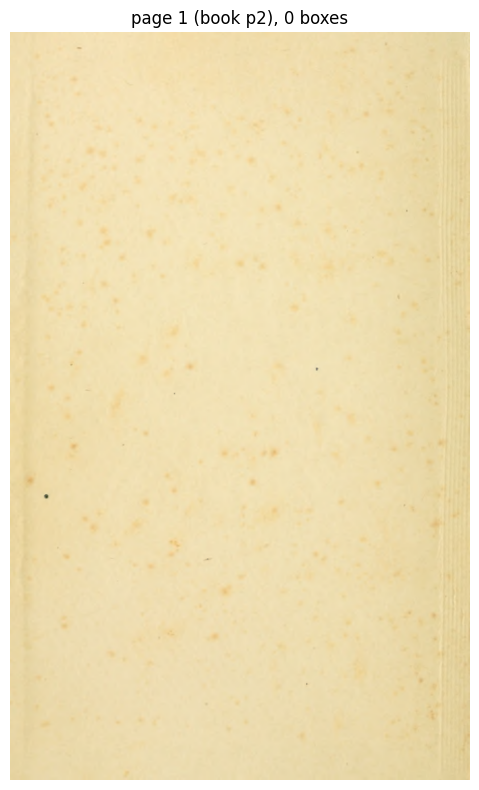

labels on the pages shown:
  page 1 (book p2): {'?': 10}


In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

figures_by_page = {}
for chunk in figures:
    figures_by_page.setdefault(int(chunk.get("page", 1)), []).append(chunk)

pages_to_show = sorted(figures_by_page)[:6] or [1]
fig, axes = plt.subplots(1, len(pages_to_show), figsize=(5 * len(pages_to_show), 8))
axes = np.atleast_1d(axes)

for ax, page in zip(axes, pages_to_show):
    pixmap = pdf_doc[page - 1].get_pixmap(dpi=150)
    image = np.frombuffer(pixmap.samples, np.uint8).reshape(
        pixmap.height, pixmap.width, pixmap.n)
    ax.imshow(image)

    span_x, span_y = EXTENT.get(page, (pixmap.width, pixmap.height))
    scale_x = pixmap.width / span_x if span_x else 1.0
    scale_y = pixmap.height / span_y if span_y else 1.0

    for chunk in figures_by_page.get(page, []):
        box = chunk.get("bbox")
        if not box or len(box) != 4:
            continue
        x0, y0 = box[0] * scale_x, box[1] * scale_y
        x1, y1 = box[2] * scale_x, box[3] * scale_y
        ax.add_patch(patches.Rectangle((x0, y0), x1 - x0, y1 - y0,
                                       fill=False, edgecolor="red", linewidth=2))
        ax.text(x0, max(y0 - 6, 0), str(chunk.get("label", "?")), color="red", fontsize=9)

    book_page = INDEX_TO_PAGE.get(str(page), page)
    ax.set_title(f"page {page} (book p{book_page}), "
                 f"{len(figures_by_page.get(page, []))} boxes")
    ax.axis("off")

plt.tight_layout()
plt.show()

print("labels on the pages shown:")
for page in pages_to_show:
    labels = Counter(str(c.get("label", "?")) for c in CHUNKS
                     if int(c.get("page", 1)) == page)
    print(f"  page {page} (book p{INDEX_TO_PAGE.get(str(page), page)}): {dict(labels)}")

## 7. Text attached to figures

Prints the content of each figure block. Text that matches the printed caption can fill
`caption_printed`, which is what a citation points at. A description written by the model
belongs in `caption_generated` and is only useful for widening search.

In [8]:
for chunk in figures[:12]:
    page = chunk.get("page", "?")
    content = (chunk.get("content") or chunk.get("text") or "").strip().replace("\n", " ")
    print(f"book p{INDEX_TO_PAGE.get(str(page), page)}  "
          f"{chunk.get('label')}  bbox={chunk.get('bbox')}")
    print(f"  {content[:300] or '(empty)'}\n")

## 8. Package the output

Writes a run summary and zips the output directory. Unzip it locally into
`development/chandra_kaggle/output/` and run `python3 parse_chandra.py output/`.

In [9]:
summary = {
    "pages": len(INDEX_TO_PAGE) or None,
    "seconds_total": round(elapsed, 1),
    "seconds_per_page": round(elapsed / (len(INDEX_TO_PAGE) or 10), 1),
    "chunks_total": len(CHUNKS),
    "figure_chunks": len(figures),
    "labels": dict(Counter(str(c.get("label", "?")) for c in CHUNKS)),
    "page_size_fields": size_fields,
    "box_extent_per_page": {str(k): v for k, v in EXTENT.items()},
    "index_to_book_page": INDEX_TO_PAGE,
}
(OUT / "run_summary.json").write_text(json.dumps(summary, indent=1))
print(json.dumps(summary, indent=1))

archive = shutil.make_archive(str(WORK / "chandra_out"), "zip", root_dir=OUT)
print(f"\n{archive}  {Path(archive).stat().st_size/1e6:.1f} MB")

{
 "pages": 10,
 "seconds_total": 746.0,
 "seconds_per_page": 74.6,
 "chunks_total": 10,
 "figure_chunks": 0,
 "labels": {
  "?": 10
 },
 "page_size_fields": [],
 "box_extent_per_page": {},
 "index_to_book_page": {
  "1": 2,
  "2": 5,
  "3": 21,
  "4": 32,
  "5": 36,
  "6": 74,
  "7": 84,
  "8": 138,
  "9": 261,
  "10": 312
 }
}

/kaggle/working/chandra_out.zip  0.3 MB
